In [1]:
import numpy as np
import matplotlib.pyplot as plt

$$
f(x) = 3x^2 + 5x + 5
$$

In [2]:
-5 / 6

-0.8333333333333334

In [3]:
def f(x):
    return 3*x**2 + 5*x + 5

def f_grad(x):
    return 6*x + 5

In [4]:
x = np.linspace(-100, 100, 10000)
y = f(x)

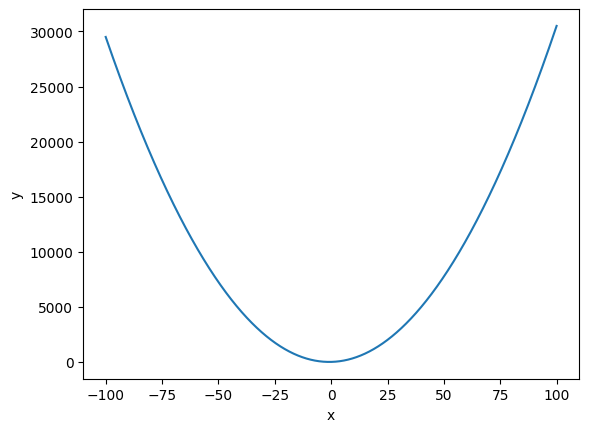

In [5]:
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel('y')
plt.show()

In [6]:
x0 = np.random.randint(low=-100, high=100)
y0 = f(x0)
(x0, y0)

(-23, 1477)

Initial x: -25
Convergence after 118 steps


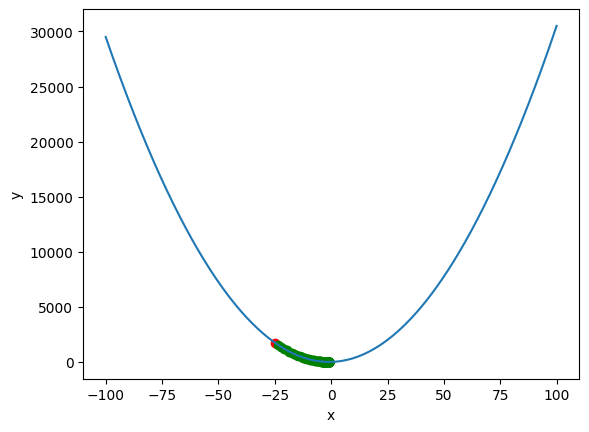

Last x: -0.849637682845275


In [7]:
# hyperparameters
lr = 0.01 # learning rate
tol = 0.001  # tolerance
max_iter = 1000 # maximum number of iterations

plt.plot(x, y)


x0 = np.random.randint(low=-100, high=100) # initialize x0 randomly
y0 = f(x0)
plt.scatter(x0, y0, c='red')

print('Initial x:', x0)


for i in range(max_iter):
    x_grad = f_grad(x0) # calculate gradient
    decay = lr * x_grad

    if abs(decay) < tol:
        print(f'Convergence after {i} steps')
        break

    x0 = x0 - decay # adjust x0 according to gradient

    y0 = f(x0)
    plt.scatter(x0, y0, c='green')


plt.xlabel("x")
plt.ylabel('y')
plt.show()

print('Last x:', x0)

## Using gradient descent to find Linear Regression coefficients

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/advertising.csv')

X = df[['TV']].values
y = df['Sales'].values

sclr = StandardScaler()
X = sclr.fit_transform(X)

$$
\hat{y} = \beta_0 + \beta_1 x
$$

$$
\frac{\partial \text{MSE}(\beta_0, \beta_1)}{\partial \beta_0} = -2*\sum_{i=1}^{N} (y - (\beta_0 + \beta_1 x))
$$

$$
\frac{\partial \text{MSE}(\beta_0, \beta_1)}{\partial \beta_1} = -2*\sum_{i=1}^{N} (y - (\beta_0 + \beta_1 x))x
$$

In [9]:
def loss(beta0, beta1):
    return np.sum((y - (beta0 + beta1 * X).ravel()) ** 2) ** 0.5 / X.shape[0]


def grad_beta(beta0, beta1):
    beta0_grad = -2 * np.sum((y - (beta0 + beta1 * X).ravel()))
    beta1_grad = -2 * np.sum((y - (beta0 + beta1 * X).ravel()) * X.ravel())
    return beta0_grad, beta1_grad

In [10]:
lr = 0.001
tol = 0.0001
max_iter = 1000

In [14]:
loss(beta0, beta1)

np.float64(0.16152002864824533)

In [15]:
beta0_grad, beta1_grad = grad_beta(beta0, beta1)
beta0_grad, beta1_grad

(np.float64(-0.06859715769552821), np.float64(-0.024334521272685095))

Convergence after 22 steps


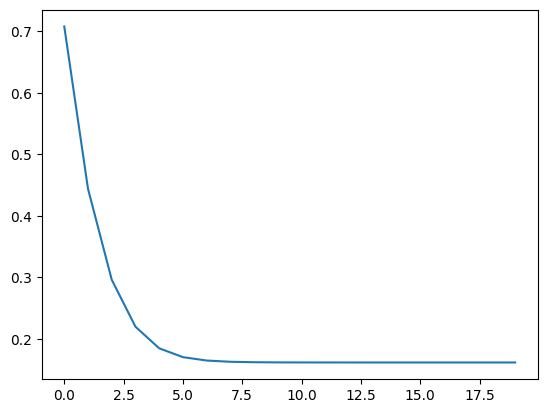

In [16]:
lossi = []

beta0 = np.random.randn()
beta1 = np.random.randn()

for i in range(max_iter):
    beta0_grad, beta1_grad = grad_beta(beta0, beta1)

    if ((lr * beta0_grad)**2 + (lr * beta1_grad)**2)**0.5 < tol:
        print(f'Convergence after {i} steps')
        break

    beta0 = beta0 - lr * beta0_grad # type: ignore
    beta1 = beta1 - lr * beta1_grad # type: ignore
    l = loss(beta0, beta1)
    lossi.append(l)


plt.plot(lossi[:20])
plt.show()

In [17]:
beta0.item(), beta1.item()

(15.130296504434314, 4.749900123534776)

In [18]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [19]:
lin_reg.coef_

array([4.74996588])

In [20]:
lin_reg.intercept_

np.float64(15.130500000000001)

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/advertising.csv')

X = df.drop(columns=['Sales']).values
y = df['Sales'].values

sclr = StandardScaler()
X = sclr.fit_transform(X)

In [32]:
import numpy as np
from sklearn.metrics import root_mean_squared_error

class BatchGradientDescend:
    def __init__(self, lr, max_iter, tol):
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None

        self.lossi = []
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n = X.shape[0]

        X = np.c_[np.ones(n), X]
        
        n_features = X.shape[1]

        # 1. Initialize coefficients randomly
        coef = np.random.randn(n_features)

        converged = False

        for i in range(self.max_iter):
            y_pred = X @ coef
            e = y - y_pred

            loss = root_mean_squared_error(y, y_pred)
            self.lossi.append(loss)
    
            # 2. Calculate gradients
            coef_grad = (-2 / n) * X.T @ e
            
            if np.linalg.norm(self.lr * coef_grad) < self.tol:
                converged = True
                break

            # 3. Adjust coefficients accordingly (using self.lr)
            coef = coef - self.lr * coef_grad

        if not converged:
            print(f"Warning: Did not converge after {self.max_iter} steps.")

        # 4. Repeat this process self.max_iter times

        self.coef_ = coef[1:]
        self.intercept_ = coef[0]
        self.step = i
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        R2 = 1 - np.sum((y - self.predict(X))**2)/np.sum((y - np.mean(y))**2)
        return R2


gd = BatchGradientDescend(lr=0.01, max_iter=1000, tol=0.001)
gd.fit(X, y)

In [31]:
gd.step

292

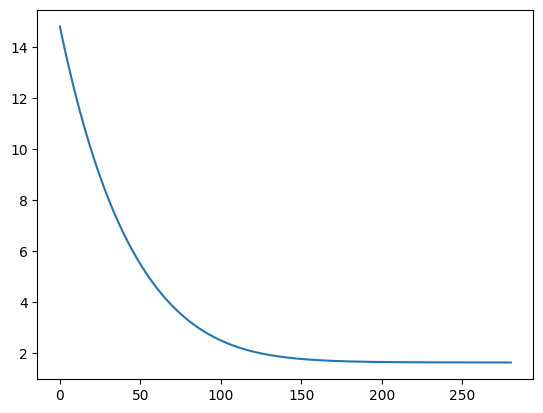

In [24]:
import matplotlib.pyplot as plt

plt.plot(gd.lossi)
plt.show()

**Batch Gradient Descend:**

$$
\frac{\partial \text{MSE}(\beta)}{\partial \beta} = \frac{1}{2N} (X^TX\beta - X^Ty) = \frac{2}{N} X^T (X\beta - y) = -\frac{2}{N} X^T \varepsilon
$$

$$
\frac{\partial \text{MSE}^{(i)}(\beta)}{\partial \beta} = -2 x^{(i)T}(y^{(i)} - x^{(i)} \beta)
$$

In [29]:
class StochasticGradientDescend:
    def __init__(self, lr, max_iter, tol):
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None

        self.lossi = []
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n = X.shape[0]

        X = np.c_[np.ones(n), X]
        
        n_features = X.shape[1]

        # 1. Initialize coefficients randomly
        coef = np.random.randn(n_features)

        converged = False

        for epoch in range(self.max_iter):
            for i in range(n):
                y_pred = X[i] @ coef

                e = y[i] - y_pred
                # print(y[i])
                # print(X[i] @ coef)
                # print(e)
                # print()

                loss = root_mean_squared_error([y[i]], [y_pred])
                self.lossi.append(loss)
        
                # 2. Calculate gradients
                coef_grad = (-2) * X[i].T * e
                
                if np.linalg.norm(self.lr * coef_grad) < self.tol:
                    converged = True
                    break

                # 3. Adjust coefficients accordingly (using self.lr)
                coef = coef - self.lr * coef_grad

        if not converged:
            print(f"Warning: Did not converge after {self.max_iter} steps.")

        # 4. Repeat this process self.max_iter times

        self.coef_ = coef[1:]
        self.intercept_ = coef[0]
        self.step = epoch
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        R2 = 1 - np.sum((y - self.predict(X))**2)/np.sum((y - np.mean(y))**2)
        return R2


sgd = StochasticGradientDescend(lr=0.01, max_iter=10, tol=0.001)
sgd.fit(X, y)

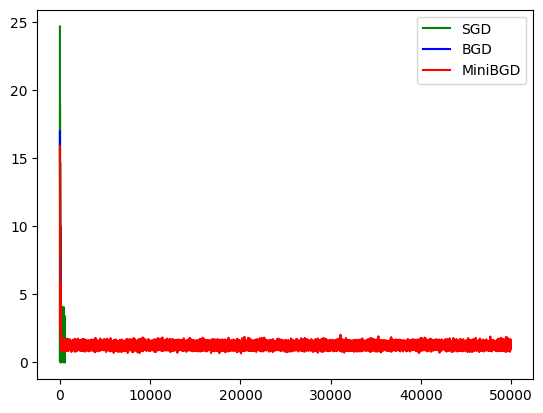

In [46]:
plt.plot(sgd.lossi, c='g', label='SGD')
plt.plot(gd.lossi, c='b', label='BGD')
plt.plot(mbgd.lossi, c='r', label='MiniBGD')
plt.legend()
plt.show()

In [27]:
BGD = 1000
SGD = 1000000

In [28]:
from sklearn.linear_model import SGDRegressor



In [45]:
class MiniBatchGradientDescend:
    def __init__(self, lr, max_iter, tol, batch_size):
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.batch_size = batch_size

        self.coef_ = None
        self.intercept_ = None

        self.lossi = []
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n = X.shape[0]

        X = np.c_[np.ones(n), X]
        
        n_features = X.shape[1]

        # 1. Initialize coefficients randomly
        coef = np.random.randn(n_features)

        converged = False

        for epoch in range(self.max_iter):
            indices = np.random.permutation(len(X))
            X = X[indices]
            y = y[indices]
            for i in range(0, n, self.batch_size):
                y_pred = X[i:i+self.batch_size] @ coef

                e = y[i:i+self.batch_size] - y_pred
                # print(y[i])
                # print(X[i] @ coef)
                # print(e)
                # print()

                loss = root_mean_squared_error([y[i:i+self.batch_size]], [y_pred])
                self.lossi.append(loss)
        
                # 2. Calculate gradients
                coef_grad = (-2 / X[i:i+self.batch_size].shape[0]) * X[i:i+self.batch_size].T @ e
                
                if np.linalg.norm(self.lr * coef_grad) < self.tol:
                    converged = True
                    break

                # 3. Adjust coefficients accordingly (using self.lr)
                coef = coef - self.lr * coef_grad

        if not converged:
            print(f"Warning: Did not converge after {self.max_iter} steps.")

        # 4. Repeat this process self.max_iter times

        self.coef_ = coef[1:]
        self.intercept_ = coef[0]
        self.step = epoch
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        R2 = 1 - np.sum((y - self.predict(X))**2)/np.sum((y - np.mean(y))**2)
        return R2


mbgd = MiniBatchGradientDescend(lr=0.01, max_iter=10000, tol=0.001, batch_size=42)
mbgd.fit(X, y)